# Выбросы

Содержание:
1. Импорты библиотек
2. 
3. 
4. 
5. 


### 1. Импорты библиотек

In [40]:
import pandas as pd
import numpy as np
import nbformat

import sweetviz as sv
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import statistics
import scipy.stats as stats

 
from IPython.display import Image

#### Настройки вывода

In [2]:
# Показать все колонки
pd.set_option('display.max_columns', None)
# Установить ширину отображения
pd.set_option('display.width', None)
# Отобразить все колонки без сокращения
pd.set_option('display.expand_frame_repr', False)

### 2. Описание данных

In [3]:
# Исходный датафрейм
df = pd.read_csv('imdb_top_1000.csv')

In [4]:
df.head(1)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"


Датасет с топ-1000 фильмов imdb

Параметры:
1) Poster_Link - ссылка на постер
2) Series_Title - название
3) Released_Year - год выхода
4) Certificate - возрастной рейтинг
5) Runtime - длительность
6) Genre - жанр
7) IMDB_Rating - рейтинг IMDB
8) Overview - описание
9) Meta_score - оценка Meta_score
10) Director - режиссер
11) Star1 - актер 1
12) Star2 - актер 2
13) Star3 - актер 3
14) Star4 - актер 4
15) No_of_Votes - число голосов
16) Gross - доход


In [7]:
df.info() ## получаем типы данных и число пропусков в колонках

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 997
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   714 non-null    object 
 1   Released_Year  714 non-null    object 
 2   Certificate    714 non-null    object 
 3   Runtime        714 non-null    int32  
 4   Genre          714 non-null    object 
 5   IMDB_Rating    714 non-null    float64
 6   Meta_score     714 non-null    float64
 7   Director       714 non-null    object 
 8   Star1          714 non-null    object 
 9   Star2          714 non-null    object 
 10  Star3          714 non-null    object 
 11  Star4          714 non-null    object 
 12  No_of_Votes    714 non-null    int64  
 13  Gross          714 non-null    object 
dtypes: float64(2), int32(1), int64(1), object(10)
memory usage: 80.9+ KB


## Выбросы

In [ ]:
## Оставляю для примера только количественные показатели
df = df[['Runtime','IMDB_Rating','Meta_score','No_of_Votes']]

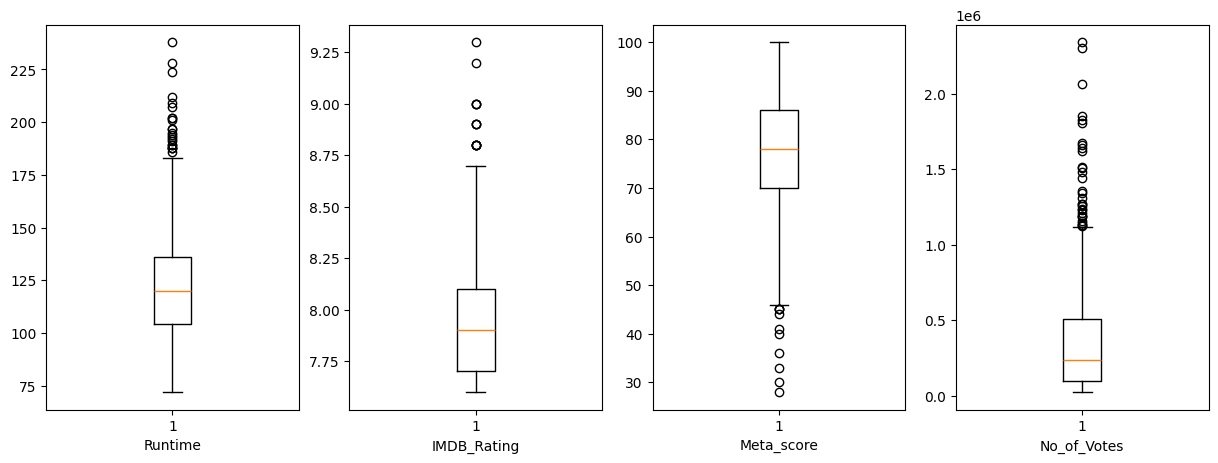

In [ ]:
### Показываем все показатели на боксплотах

matplotlib.rcParams['figure.figsize'] = (15, 5)
for i,j in enumerate(df.columns):
    plt.subplot(1, 4, i+1) # (rows, columns, panel number)
    plt.boxplot(df[j])
    plt.xlabel(j)

## Видим выбросы


In [ ]:
z = df.apply(stats.zscore)
z.head() ## на сколько средних квадратических отклонений каждое значение отличается от среднего

,Runtime,IMDB_Rating,Meta_score,No_of_Votes
0,0.706793,4.650337,0.229312,5.618428
1,1.982431,4.309124,1.843197,3.574779
2,1.093350,3.626699,0.552089,5.505668
3,3.026136,3.626699,1.036254,2.188068
4,-1.071369,3.626699,1.520420,0.943609


In [43]:
df[(np.abs(z) > 3).any(axis = 1)].head()

,Runtime,IMDB_Rating,Meta_score,No_of_Votes
0,142,9.3,80.0,2343110
1,175,9.2,100.0,1620367
2,152,9.0,84.0,2303232
3,202,9.0,90.0,1129952
4,96,9.0,96.0,689845
